# 02  -  Data Cleaning

**Ziel:** Rohdaten (Velozählstellen Zürich) bereinigen und als analyse-fertige Datasets speichern.

**Relevanz für unsere Forschungsfragen:**
- **FF1 (Nachfrage-Ranking):** Braucht saubere, lückenlose Zähldaten pro Station über alle Jahre
- **FF2 (Wachstums-Hotspots):** Braucht konsistente Stationsverfügbarkeit über die Jahre  -  Stationen die nicht alle Jahre aktiv sind verfälschen den Trend

**Cleaning-Plan:**

| # | Schritt | Betrifft |
|---|---------|----------|
| 1 | Jahres-CSVs zusammenführen, Spalten bereinigen | Velo |
| 2 | Nur Velo-Stationen behalten (Fussgänger raus) | Velo |
| 3 | Datetime parsen, Frequenz prüfen, Lücken identifizieren | Velo |
| 4 | Uni-direktionale Stationen erkennen, Total berechnen | Velo |
| 5 | Sensor-Ausfälle erkennen (lange Null-Serien → NaN) | Velo |
| 6 | Stationskonsistenz über Jahre prüfen (für FF2) | Velo |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

# Cleaning log  -  we track every decision
cleaning_log = []

def log_step(step, description, rows_affected, detail=""):
    cleaning_log.append({
        "step": step,
        "description": description,
        "rows_affected": rows_affected,
        "detail": detail,
    })
    print(f"[Step {step}] {description}  -  {rows_affected:,} rows affected. {detail}")

---
## Teil 1: Velozähldaten Zürich

### 1.1 Jahres-CSVs laden und zusammenführen

Die Rohdaten liegen als separate CSVs pro Jahr vor (2020-2025). Jede Datei enthält sowohl Velo- als auch Fussgänger-Zählstellen.

In [2]:
# Load and concatenate all year files
files = sorted(glob.glob("../data/20*_verkehrszaehlungen_werte_fussgaenger_velo.csv"))
print(f"Found {len(files)} files:")

dfs = []
for f in files:
    tmp = pd.read_csv(f)
    year = os.path.basename(f)[:4]
    print(f"  {os.path.basename(f)}: {len(tmp):>10,} rows, {tmp['FK_STANDORT'].nunique()} stations")
    dfs.append(tmp)

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nCombined: {len(df_raw):,} rows, {df_raw['FK_STANDORT'].nunique()} unique stations")
print(f"Columns: {df_raw.columns.tolist()}")
print(f"\nNull counts:\n{df_raw.isnull().sum()}")
print(f"\nDtypes:\n{df_raw.dtypes}")

Found 6 files:


  2020_verkehrszaehlungen_werte_fussgaenger_velo.csv:  1,257,695 rows, 49 stations


  2021_verkehrszaehlungen_werte_fussgaenger_velo.csv:  1,178,570 rows, 46 stations


  2022_verkehrszaehlungen_werte_fussgaenger_velo.csv:  1,189,238 rows, 47 stations


  2023_verkehrszaehlungen_werte_fussgaenger_velo.csv:    949,660 rows, 46 stations


  2024_verkehrszaehlungen_werte_fussgaenger_velo.csv:    918,683 rows, 27 stations


  2025_verkehrszaehlungen_werte_fussgaenger_velo.csv:    853,565 rows, 28 stations

Combined: 6,347,411 rows, 83 unique stations
Columns: ['FK_STANDORT', 'DATUM', 'VELO_IN', 'VELO_OUT', 'FUSS_IN', 'FUSS_OUT', 'OST', 'NORD']

Null counts:
FK_STANDORT          0
DATUM                0
VELO_IN        1847736
VELO_OUT       2420725
FUSS_IN        4493339
FUSS_OUT       4493339
OST                  0
NORD                 0
dtype: int64

Dtypes:
FK_STANDORT      int64
DATUM              str
VELO_IN        float64
VELO_OUT       float64
FUSS_IN        float64
FUSS_OUT       float64
OST              int64
NORD             int64
dtype: object


In [3]:
# Rename columns to clean, descriptive names
df = df_raw.rename(columns={
    "FK_STANDORT": "station_id",
    "DATUM": "datetime",
    "VELO_IN": "velo_in",
    "VELO_OUT": "velo_out",
    "FUSS_IN": "fuss_in",
    "FUSS_OUT": "fuss_out",
    "OST": "easting",   # LV95 coordinates
    "NORD": "northing",
})

log_step("1.1", "Loaded and concatenated yearly CSVs, renamed columns", len(df))

[Step 1.1] Loaded and concatenated yearly CSVs, renamed columns  -  6,347,411 rows affected. 


### 1.2 Nur Velo-Stationen behalten

Die Rohdaten enthalten gemischte Velo- und Fussgänger-Zählstellen. Wir behalten nur Stationen die Velodaten haben  -  Fussgänger-Spalten werden anschliessend entfernt.

In [4]:
# Identify station types: velo-only, fuss-only, both
has_velo = df.groupby("station_id")["velo_in"].apply(lambda x: x.notnull().any())
has_fuss = df.groupby("station_id")["fuss_in"].apply(lambda x: x.notnull().any())

velo_stations = has_velo[has_velo].index
fuss_only_stations = has_fuss[~has_velo & has_fuss].index

print(f"Stations with velo data: {len(velo_stations)}")
print(f"Stations with fuss only: {len(fuss_only_stations)} (will be dropped)")
print(f"Stations with both:      {(has_velo & has_fuss).sum()}")

# Filter to velo stations only
n_before = len(df)
df = df[df["station_id"].isin(velo_stations)].copy()

# Drop pedestrian columns  -  not relevant for our questions
df = df.drop(columns=["fuss_in", "fuss_out"])

log_step("1.2", "Filtered to velo-only stations, dropped fuss columns",
         n_before - len(df), f"Kept {df['station_id'].nunique()} stations")

Stations with velo data: 46
Stations with fuss only: 37 (will be dropped)
Stations with both:      2


[Step 1.2] Filtered to velo-only stations, dropped fuss columns  -  1,847,736 rows affected. Kept 46 stations


### 1.3 Datetime parsen und Duplikate prüfen

In [5]:
# Parse datetime
df["datetime"] = pd.to_datetime(df["datetime"], format="%Y-%m-%dT%H:%M")

print(f"Date range: {df['datetime'].min()} to {df['datetime'].max()}")

# Check for duplicates (same station + same timestamp should not exist)
n_dupes = df.duplicated(subset=["station_id", "datetime"]).sum()
print(f"\nDuplicate (station_id, datetime) pairs: {n_dupes}")

if n_dupes > 0:
    # Inspect before dropping
    dupes = df[df.duplicated(subset=["station_id", "datetime"], keep=False)]
    print(dupes.sort_values(["station_id", "datetime"]).head(10))
    df = df.drop_duplicates(subset=["station_id", "datetime"], keep="first")
    log_step("1.3", "Removed duplicate station+datetime rows", n_dupes)
else:
    log_step("1.3", "Parsed datetime, no duplicates found", 0)

# Extract time components (needed throughout)
df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.weekday  # 0=Mon, 6=Sun

df.head()

Date range: 2020-01-01 00:00:00 to 2025-12-31 23:45:00



Duplicate (station_id, datetime) pairs: 512


         station_id            datetime  velo_in  velo_out  easting  northing
1021590          60 2020-10-25 02:00:00      0.0       0.0  2682731   1247708
1021591          60 2020-10-25 02:00:00      1.0       0.0  2682731   1247708
1021661          60 2020-10-25 02:15:00      1.0       0.0  2682731   1247708
1021662          60 2020-10-25 02:15:00      2.0       0.0  2682731   1247708
1021796          60 2020-10-25 02:30:00      0.0       0.0  2682731   1247708
1021797          60 2020-10-25 02:30:00      0.0       0.0  2682731   1247708
1021804          60 2020-10-25 02:45:00      1.0       0.0  2682731   1247708
1021805          60 2020-10-25 02:45:00      0.0       0.0  2682731   1247708
2241750          60 2021-10-31 02:00:00      1.0       0.0  2682731   1247708
2241751          60 2021-10-31 02:00:00      0.0       6.0  2682731   1247708


[Step 1.3] Removed duplicate station+datetime rows  -  512 rows affected. 


,station_id,datetime,velo_in,velo_out,easting,northing,year,month,hour,weekday
0,3927,2020-01-01,1.0,1.0,2682873,1245891,2020,1,0,2
1,2977,2020-01-01,1.0,NaN,2682681,1250570,2020,1,0,2
2,3923,2020-01-01,0.0,0.0,2681385,1247736,2020,1,0,2
3,2979,2020-01-01,0.0,0.0,2681858,1251991,2020,1,0,2
4,60,2020-01-01,0.0,0.0,2682731,1247708,2020,1,0,2


### 1.4 Uni-direktionale Stationen und Total berechnen

Einige Stationen messen nur eine Richtung (`velo_in` vorhanden, `velo_out` komplett NaN). Für diese Stationen ist `velo_in` bereits das Gesamtvolumen. Für bi-direktionale Stationen berechnen wir `velo_total = velo_in + velo_out`.

In [6]:
# Classify stations as uni- or bi-directional
station_direction = df.groupby("station_id").agg(
    has_in=("velo_in", lambda x: x.notnull().any()),
    has_out=("velo_out", lambda x: x.notnull().any()),
    pct_out_null=("velo_out", lambda x: x.isnull().mean() * 100),
).reset_index()

uni_directional = station_direction[~station_direction["has_out"]]["station_id"].values
bi_directional = station_direction[station_direction["has_out"]]["station_id"].values

print(f"Bi-directional stations (IN + OUT):  {len(bi_directional)}")
print(f"Uni-directional stations (IN only):  {len(uni_directional)}")
print(f"  Uni-directional IDs: {sorted(uni_directional)}")

# Compute total volume
# Bi-directional: total = in + out
# Uni-directional: total = in (already represents total through-traffic)
df["velo_total"] = np.where(
    df["station_id"].isin(uni_directional),
    df["velo_in"],
    df["velo_in"].fillna(0) + df["velo_out"].fillna(0),
)

# Flag direction type for reference
df["is_bidirectional"] = df["station_id"].isin(bi_directional)

log_step("1.4", "Computed velo_total (uni/bi-directional aware)", 0,
         f"{len(uni_directional)} uni-directional, {len(bi_directional)} bi-directional")

Bi-directional stations (IN + OUT):  39
Uni-directional stations (IN only):  7
  Uni-directional IDs: [np.int64(62), np.int64(2977), np.int64(2982), np.int64(3008), np.int64(4258), np.int64(4267), np.int64(4272)]
[Step 1.4] Computed velo_total (uni/bi-directional aware)  -  0 rows affected. 7 uni-directional, 39 bi-directional


### 1.5 Sensor-Ausfälle erkennen

Lange zusammenhängende Null-Serien (z.B. > 6 Stunden = 24 Intervalle à 15 Min) sind fast sicher Sensor-Ausfälle, nicht echtes Null-Aufkommen. Echte Nullen (z.B. nachts um 3 Uhr) sind dagegen plausibel und kurz.

**Strategie:** Zusammenhängende Null-Serien > 24 Intervalle (6h) werden als Sensor-Ausfall markiert und auf NaN gesetzt.

In [7]:
ZERO_RUN_THRESHOLD = 24  # 24 × 15min = 6 hours

def flag_suspicious_zeros(group):
    """Flag zero-runs longer than threshold as sensor failure."""
    is_zero = group["velo_total"] == 0
    # Create groups of consecutive equal values
    groups = is_zero.ne(is_zero.shift()).cumsum()
    consecutive_len = is_zero.groupby(groups).transform("sum")
    return is_zero & (consecutive_len > ZERO_RUN_THRESHOLD)

# Apply per station (zero-runs should be detected within each station)
df["sensor_failure"] = df.groupby("station_id", group_keys=False).apply(flag_suspicious_zeros)

n_flagged = df["sensor_failure"].sum()
n_stations_affected = df[df["sensor_failure"]]["station_id"].nunique()

print(f"Rows flagged as sensor failure: {n_flagged:,}")
print(f"Stations affected: {n_stations_affected}")

# Show worst affected stations
failure_by_station = df[df["sensor_failure"]].groupby("station_id").size().sort_values(ascending=False)
print(f"\nTop 10 affected stations:")
print(failure_by_station.head(10))

# Set sensor failures to NaN
df.loc[df["sensor_failure"], ["velo_in", "velo_out", "velo_total"]] = np.nan

log_step("1.5", "Flagged long zero-runs as sensor failure → NaN", n_flagged,
         f"{n_stations_affected} stations affected, threshold={ZERO_RUN_THRESHOLD} intervals (6h)")

Rows flagged as sensor failure: 68,615
Stations affected: 27

Top 10 affected stations:
station_id
4257    29104
3008     7322
4255     5478
2978     4670
1692     4247
4269     3932
3927     3778
3924     2417
53       1982
5002     1633
dtype: int64
[Step 1.5] Flagged long zero-runs as sensor failure → NaN  -  68,615 rows affected. 27 stations affected, threshold=24 intervals (6h)


### 1.6 Negative Werte und Range-Validierung

In [8]:
# Negative values are physically impossible for counts
n_negative_in = (df["velo_in"] < 0).sum()
n_negative_out = (df["velo_out"] < 0).sum()
print(f"Negative velo_in:  {n_negative_in}")
print(f"Negative velo_out: {n_negative_out}")

if n_negative_in + n_negative_out > 0:
    df.loc[df["velo_in"] < 0, "velo_in"] = np.nan
    df.loc[df["velo_out"] < 0, "velo_out"] = np.nan
    # Recompute total
    df["velo_total"] = np.where(
        df["station_id"].isin(uni_directional),
        df["velo_in"],
        df["velo_in"].fillna(0) + df["velo_out"].fillna(0),
    )

# Sanity check: max value per 15-min interval
print(f"\nvelo_total range: {df['velo_total'].min():.0f} - {df['velo_total'].max():.0f}")
print(f"99.9th percentile: {df['velo_total'].quantile(0.999):.0f}")

# Flag extreme values (> 99.9th percentile) for review but don't remove
p999 = df["velo_total"].quantile(0.999)
n_extreme = (df["velo_total"] > p999).sum()
print(f"Rows above 99.9th percentile ({p999:.0f}): {n_extreme}")

log_step("1.6", "Validated ranges, set negative values to NaN", n_negative_in + n_negative_out)

Negative velo_in:  0
Negative velo_out: 0

velo_total range: 0 - 1086
99.9th percentile: 155
Rows above 99.9th percentile (155): 4345
[Step 1.6] Validated ranges, set negative values to NaN  -  0 rows affected. 


### 1.7 Stationskonsistenz über Jahre prüfen (kritisch für FF2)

Für die Wachstumsanalyse (FF2) brauchen wir Stationen die über den gesamten Zeitraum konsistent Daten liefern. Stationen die erst 2023 hinzukamen oder 2022 abgeschaltet wurden, verfälschen den Trend.

Stations with ≥60% coverage ALL years 2020-2024: 6
Stations with ≥60% coverage 2022-2024:           12

Note: Zürich replaced many older stations with new ones around 2022-2023.
For FF2 growth analysis, the 2022-2024 window is more practical.


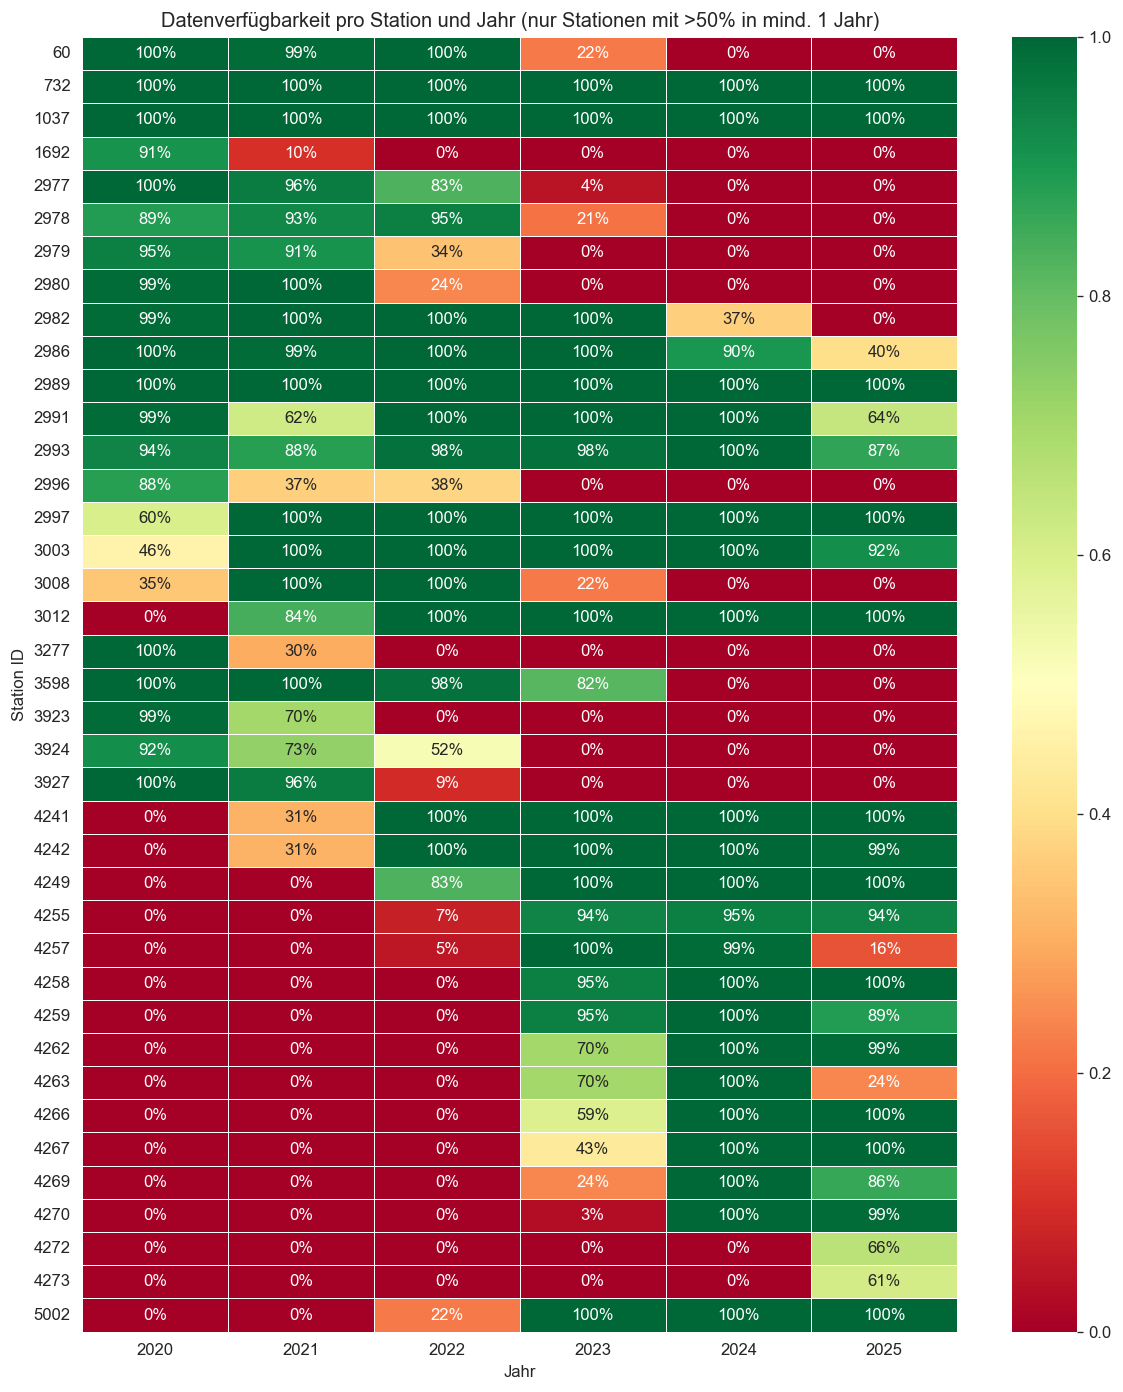

[Step 1.7] Identified stations with consistent multi-year coverage  -  0 rows affected. 6 full-span (2020-24), 12 recent (2022-24)


In [9]:
# For each station: which years have substantial data?
# "Substantial" = at least 60% of expected rows for that year (non-NaN velo_total)
COVERAGE_THRESHOLD = 0.60
INTERVALS_PER_YEAR = 365.25 * 24 * 4  # ~35,064

station_year = df.groupby(["station_id", "year"]).agg(
    total_rows=("velo_total", "size"),
    valid_rows=("velo_total", "count"),  # non-NaN
).reset_index()
station_year["coverage"] = station_year["valid_rows"] / INTERVALS_PER_YEAR

# Pivot for visualization
coverage_pivot = station_year.pivot(index="station_id", columns="year", values="coverage").fillna(0)

# The Zürich station network changed significantly: many old stations decommissioned,
# many new ones added from 2022+. We check two windows:
# - Full span 2020-2024 (strict, for long-term trend)
# - Recent span 2022-2024 (more stations, for shorter trend)
full_years = [2020, 2021, 2022, 2023, 2024]
recent_years = [2022, 2023, 2024]

full_cols = [y for y in full_years if y in coverage_pivot.columns]
recent_cols = [y for y in recent_years if y in coverage_pivot.columns]

consistent_full = (coverage_pivot[full_cols] >= COVERAGE_THRESHOLD).all(axis=1)
consistent_recent = (coverage_pivot[recent_cols] >= COVERAGE_THRESHOLD).all(axis=1)

consistent_stations_full = consistent_full[consistent_full].index.tolist()
consistent_stations_recent = consistent_recent[consistent_recent].index.tolist()
# Use the broader set (recent) as default
consistent_stations = consistent_stations_recent

print(f"Stations with ≥{COVERAGE_THRESHOLD*100:.0f}% coverage ALL years 2020-2024: {len(consistent_stations_full)}")
print(f"Stations with ≥{COVERAGE_THRESHOLD*100:.0f}% coverage 2022-2024:           {len(consistent_stations_recent)}")
print(f"\nNote: Zürich replaced many older stations with new ones around 2022-2023.")
print(f"For FF2 growth analysis, the 2022-2024 window is more practical.")

# Visualize coverage matrix (only stations with >50% in any year)
has_data = (coverage_pivot > 0.5).any(axis=1)
plot_data = coverage_pivot[has_data]

fig, ax = plt.subplots(figsize=(10, max(6, len(plot_data) * 0.3)))
sns.heatmap(
    plot_data.round(2),
    annot=True, fmt=".0%", cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.5, ax=ax,
)
ax.set_title("Datenverfügbarkeit pro Station und Jahr (nur Stationen mit >50% in mind. 1 Jahr)")
ax.set_ylabel("Station ID")
ax.set_xlabel("Jahr")
plt.tight_layout()
plt.show()

log_step("1.7", "Identified stations with consistent multi-year coverage", 0,
         f"{len(consistent_stations_full)} full-span (2020-24), {len(consistent_stations_recent)} recent (2022-24)")

In [10]:
# Save the consistent station list as a column for easy filtering later
df["is_consistent"] = df["station_id"].isin(consistent_stations)

# Build station metadata table
station_meta = df.groupby("station_id").agg(
    easting=("easting", "first"),
    northing=("northing", "first"),
    is_bidirectional=("is_bidirectional", "first"),
    is_consistent=("is_consistent", "first"),
    first_date=("datetime", "min"),
    last_date=("datetime", "max"),
    total_valid_rows=("velo_total", "count"),
).reset_index()

print(f"Station metadata: {len(station_meta)} stations")
station_meta.head(10)

# Anreicherung mit Standortname (bezeichnung) aus dem Geoportal-Datensatz
# (heruntergeladen in Notebook 01 als data/standorte_velo_fuss.json).
# Das Feld `id1` der GeoJSON-Features entspricht direkt der `station_id`
# (= FK_STANDORT) in den Zaehldaten.
import json as _json

_standorte_path = "../data/standorte_velo_fuss.json"
try:
    with open(_standorte_path, "r", encoding="utf-8") as _f:
        _geo = _json.load(_f)
    _name_map = {
        feat["properties"]["id1"]: feat["properties"]["bezeichnung"]
        for feat in _geo["features"]
        if feat["properties"].get("id1") is not None
    }
    station_meta["station_name"] = station_meta["station_id"].map(_name_map)
    n_named = station_meta["station_name"].notna().sum()
    print(f"Standortnamen ergaenzt: {n_named}/{len(station_meta)} Stationen mit Namen")
    missing = station_meta[station_meta["station_name"].isna()]["station_id"].tolist()
    if missing:
        print(f"  Ohne Namen (selten - meist Zaehler ohne id1-Eintrag): {missing[:10]}")
except FileNotFoundError:
    print(f"Hinweis: {_standorte_path} nicht gefunden - Notebook 01 zuerst ausfuehren.")
    station_meta["station_name"] = pd.NA


Station metadata: 46 stations


Standortnamen ergaenzt: 46/46 Stationen mit Namen


### 1.8 Velo-Daten: Missing-Data-Übersicht nach Bereinigung

=== Velo data after cleaning ===
Total rows: 4,499,163
Stations: 46
  Consistent (for FF2): 48.7% of rows

Null counts:
velo_in        68615
velo_out      633691
velo_total     68615
dtype: int64

velo_total null rate: 1.5%


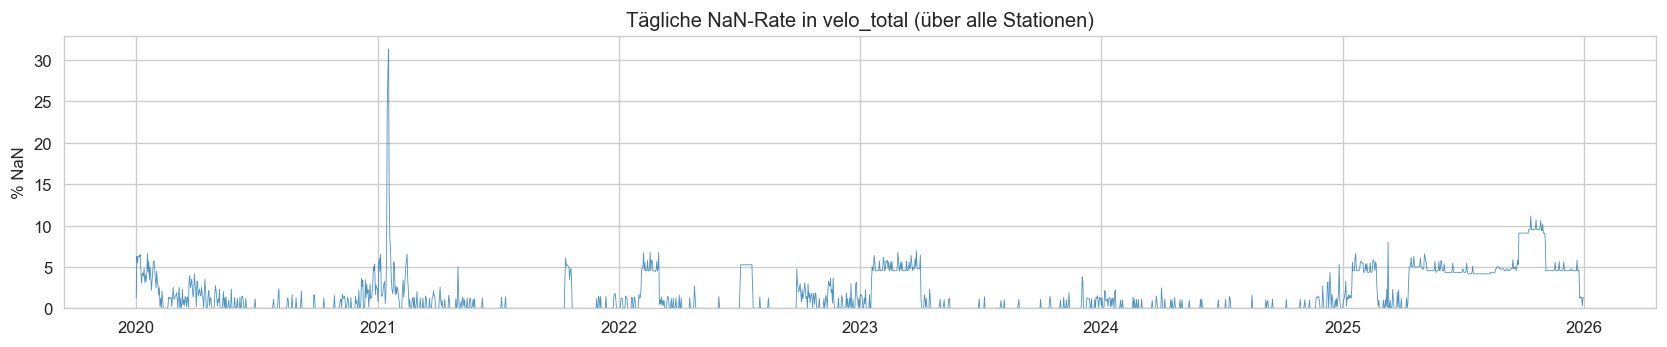

In [11]:
# Missing data overview after cleaning
print("=== Velo data after cleaning ===")
print(f"Total rows: {len(df):,}")
print(f"Stations: {df['station_id'].nunique()}")
print(f"  Consistent (for FF2): {df['is_consistent'].sum() / len(df) * 100:.1f}% of rows")
print(f"\nNull counts:")
print(df[["velo_in", "velo_out", "velo_total"]].isnull().sum())
print(f"\nvelo_total null rate: {df['velo_total'].isnull().mean()*100:.1f}%")

# Visualize missing data over time (aggregated across all stations)
daily_null_rate = (
    df.groupby(df["datetime"].dt.date)["velo_total"]
    .apply(lambda x: x.isnull().mean() * 100)
)

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(daily_null_rate.index, daily_null_rate.values, linewidth=0.5, alpha=0.8)
ax.set_ylabel("% NaN")
ax.set_title("Tägliche NaN-Rate in velo_total (über alle Stationen)")
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

---
## Teil 2: Export  -  Bereinigte Daten speichern

Wir speichern zwei Outputs:
1. **`velo_15min_clean.parquet`**  -  15-Min-Velodaten (alle Stationen, bereinigt) → für FF1 (Demand Ranking) und FF2 (Wachstums-Hotspots)
2. **`station_metadata.csv`**  -  Stationsmetadaten (Koordinaten, Typ, Konsistenz-Flag)

In [12]:
# Create output directory
os.makedirs("../data/clean", exist_ok=True)

# 1. Velo 15-min (for FF1 demand analysis and FF2 growth hotspots)
velo_export_cols = [
    "station_id", "datetime", "velo_in", "velo_out", "velo_total",
    "easting", "northing", "year", "month", "hour", "weekday",
    "is_bidirectional", "is_consistent", "sensor_failure",
]
df[velo_export_cols].to_parquet("../data/clean/velo_15min_clean.parquet", index=False)
print(f"Saved velo_15min_clean.parquet: {len(df):,} rows")

# 2. Station metadata
station_meta.to_csv("../data/clean/station_metadata.csv", index=False)
print(f"Saved station_metadata.csv: {len(station_meta)} stations")

Saved velo_15min_clean.parquet: 4,499,163 rows
Saved station_metadata.csv: 46 stations


---
## Cleaning Log & Assertions

In [13]:
# Full cleaning log
log_df = pd.DataFrame(cleaning_log)
print("=== CLEANING LOG ===\n")
for _, row in log_df.iterrows():
    print(f"[{row['step']}] {row['description']}")
    print(f"     Rows affected: {row['rows_affected']:,}")
    if row['detail']:
        print(f"     Detail: {row['detail']}")
    print()

=== CLEANING LOG ===

[1.1] Loaded and concatenated yearly CSVs, renamed columns
     Rows affected: 6,347,411

[1.2] Filtered to velo-only stations, dropped fuss columns
     Rows affected: 1,847,736
     Detail: Kept 46 stations

[1.3] Removed duplicate station+datetime rows
     Rows affected: 512

[1.4] Computed velo_total (uni/bi-directional aware)
     Rows affected: 0
     Detail: 7 uni-directional, 39 bi-directional

[1.5] Flagged long zero-runs as sensor failure → NaN
     Rows affected: 68,615
     Detail: 27 stations affected, threshold=24 intervals (6h)

[1.6] Validated ranges, set negative values to NaN
     Rows affected: 0

[1.7] Identified stations with consistent multi-year coverage
     Rows affected: 0
     Detail: 6 full-span (2020-24), 12 recent (2022-24)



In [14]:
# Final assertions  -  these should all pass if the cleaning was correct
print("Running final assertions...\n")

# Velo 15-min
assert df["velo_total"].dropna().min() >= 0, "Negative velo_total values remain!"
assert pd.api.types.is_datetime64_any_dtype(df["datetime"]), "datetime not parsed!"
assert not df.duplicated(subset=["station_id", "datetime"]).any(), "Duplicates remain!"
print("[OK] Velo 15-min: no negatives, datetime parsed, no duplicates")

# Station consistency
assert len(consistent_stations) > 5, f"Only {len(consistent_stations)} consistent stations  -  check coverage threshold"
print(f"[OK] {len(consistent_stations)} consistent stations available for FF2 (2022-2024 window)")
print(f"     {len(consistent_stations_full)} stations available for full 2020-2024 span")

print("\nAll assertions passed.")

Running final assertions...



[OK] Velo 15-min: no negatives, datetime parsed, no duplicates
[OK] 12 consistent stations available for FF2 (2022-2024 window)
     6 stations available for full 2020-2024 span

All assertions passed.


---
## Zusammenfassung der Cleaning-Entscheidungen

| Entscheidung | Begründung | Auswirkung |
|-------------|------------|------------|
| Fussgänger-Stationen entfernt | Nicht relevant für unsere Fragestellungen | ~50% der Stationen entfernt |
| Uni-/bi-direktionale Stationen unterschieden | `velo_total` muss korrekt berechnet werden  -  sonst Doppelzählung oder Unterzählung | Korrekte Volumenzahlen |
| Null-Serien >6h → NaN | Sensor-Ausfälle, kein echtes Null-Aufkommen | Verhindert Verzerrung bei Mittelwerten |
| Stationskonsistenz-Flag (`is_consistent`) | FF2 braucht Stationen mit Daten über alle Jahre  -  sonst falsches Wachstum | Nur konsistente Stationen für Trendanalyse |

### Output-Datasets für die Analyse

| Datei | Verwendung | Granularität |
|-------|-----------|-------------|
| `data/clean/velo_15min_clean.parquet` | FF1 (Nachfrage-Ranking), FF2 (Wachstums-Hotspots) | 15 Min × Station |
| `data/clean/station_metadata.csv` | Stationsübersicht | 1 Zeile pro Station |